In [1]:
from xaikd import datasets, lrp, attributors, models, utils, explainers
import numpy as np
from torch.utils.data import random_split, TensorDataset, DataLoader
import torch
from torchvision import transforms
from matplotlib import pyplot as plt

from PIL import Image

/home/pat/projects/xai-kd/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = datasets.construct("imagenet-butterfly")

In [3]:
x = dataset.input_transformation(Image.open("../../tests/data/castle.jpg"))

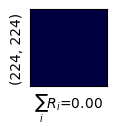

In [13]:
from matplotlib.colors import ListedColormap

def _heatmap(
    heatmap,
    title="",
    logit=None,
    reference_heatmap=None,
    total_score=None,
    grid_steps=4,
    fontsize=None,
):
    """Plot heatmap; this is adapted from https://git.tu-berlin.de/gmontavon/lrp-tutorial/-/blob/main/utils.py

    Args:
        heatmap np.array(h, w):
        reference_heatmap (np.array(h, w), optional): used for calculating normalization values. Defaults to None.
        total_score (float, optional): used for normalizing scores. Defaults to None.
    """
    assert len(heatmap.shape) == 2

    if reference_heatmap is None:
        reference_heatmap = heatmap

    assert len(reference_heatmap.shape) == 2

    b = np.abs(reference_heatmap).max()

    my_cmap = plt.cm.seismic(np.arange(plt.cm.seismic.N))
    my_cmap[:, 0:3] *= 0.85
    my_cmap = ListedColormap(my_cmap)

    sum_Ri = np.sum(heatmap)

    plt.xticks([])
    plt.yticks([])
    plt.imshow(heatmap, cmap=my_cmap, vmin=-b, vmax=b)
    plt.ylabel(heatmap.shape)
    plt.xlabel(f"$\sum_i R_i$={sum_Ri:.2f}")

plt.figure(figsize=(1, 1))
_heatmap(np.zeros((224, 224)))

In [5]:
mean, std = dataset.input_statistics

mean = torch.tensor(mean).reshape(1, 3, 1, 1)
std = torch.tensor(std).reshape(1, 3, 1, 1)

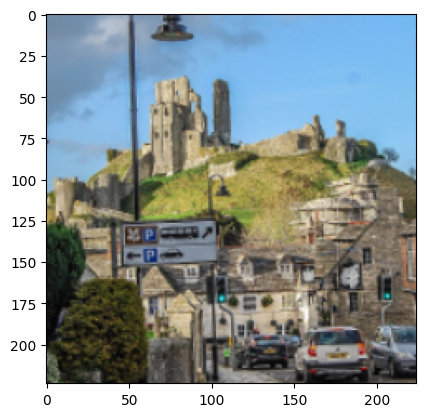

In [6]:
x_recovered = x.unsqueeze(0) * std + mean
x_recovered = torch.permute(x_recovered, [0, 2, 3, 1]).detach().numpy().squeeze()
plt.imshow(x_recovered)

In [7]:
input_transform = transforms.Normalize(*dataset.input_statistics)

In [14]:
def get_heatmaps(model_name, explainer_name, arr_targets):
    model = models.get_trained_model(model_name)
    
    explainer = explainers.get_explainer(explainer_name, model, input_transform)
    
    arr_logits = []
    arr_heatmaps = []
    
    for target in arr_targets: 
        y = torch.tensor([target])

        ds = TensorDataset(x.unsqueeze(0), y)

        dl = DataLoader(ds)

        logits, heatmaps = explainer.explain(
            dl,
            attributors.TargetClassEvidence(num_classes=1000)
        )
        arr_heatmaps.append(heatmaps[0])
        arr_logits.append(logits[0, target])

    return arr_logits, arr_heatmaps

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.45it/s]


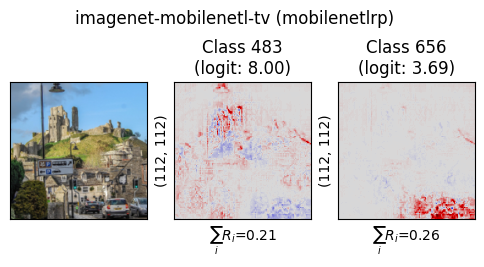

In [16]:
def viz(model_name, explainer_name, arr_targets=[483, 656]):
    
    ncols = len(arr_targets) + 1
    nrows = 1
    plt.figure(figsize=(2*ncols, 2*nrows))
    plt.suptitle(f"{model_name} ({explainer_name})", y=1.2)
    
    plt.subplot(nrows, ncols, 1)
    plt.imshow(x_recovered); plt.xticks([]); plt.yticks([])
    arr_logits, arr_heatmaps = get_heatmaps(model_name, explainer_name, arr_targets)
    
    for ix, target in enumerate(arr_targets):
        plt.subplot(nrows, ncols, ix+2)
        logit = arr_logits[ix]
        plt.title(f"Class {target}\n(logit: {logit:.2f})")
        
        _heatmap(arr_heatmaps[ix])
        
viz("imagenet-mobilenetl-tv", "mobilenetlrp")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.13it/s]


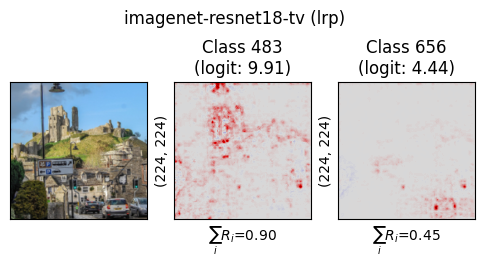

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.05it/s]


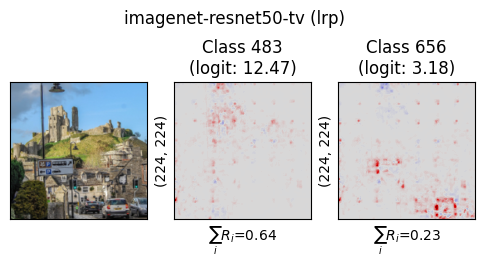

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.61s/it]


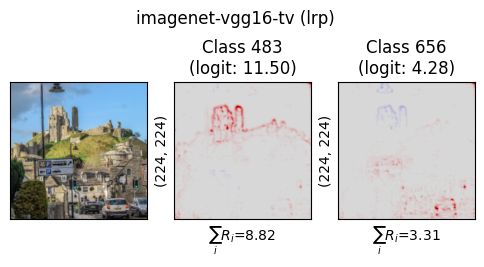

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.33s/it]


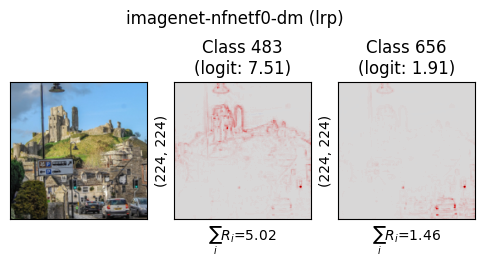

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:04<00:00,  4.46s/it]


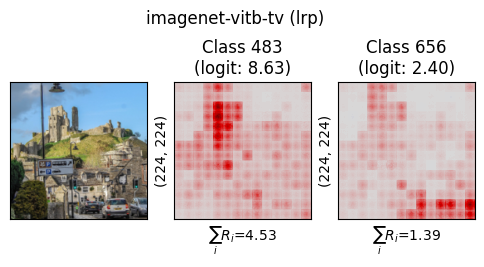

In [19]:
for model_name in [
    "imagenet-resnet18-tv",
    "imagenet-resnet50-tv",
    "imagenet-vgg16-tv",
    "imagenet-nfnetf0-dm",
    "imagenet-vitb-tv",
]:
    viz(model_name, "lrp")
    plt.show()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.45it/s]


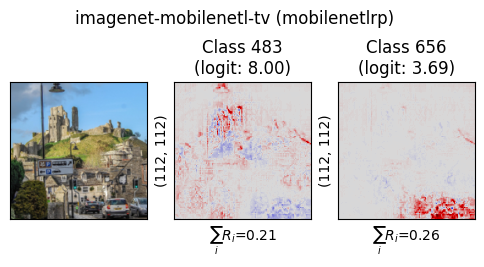

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.14it/s]


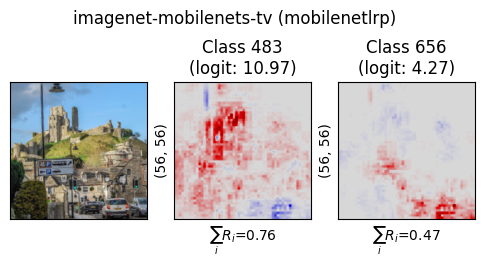

In [20]:
for model_name in [
    "imagenet-mobilenetl-tv",
    "imagenet-mobilenets-tv"
]:
    viz(model_name, "mobilenetlrp")
    plt.show()